In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Wedge
import numpy as np
from geodistpy import geodist
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import transform
from geodistpy import geodist_to_many

In [2]:
#Read in IBTrACS North Atlantic file

ibtracs=xr.open_dataset('IBTrACS.NA.v04r01.nc')
print(ibtracs)

getfattr: /home/hildebr1/ATMS: No such file or directory
getfattr: 596/Ophelia2005/IBTrACS.NA.v04r01.nc: No such file or directory


<xarray.Dataset> Size: 648MB
Dimensions:           (storm: 2317, date_time: 360, quadrant: 4)
Coordinates:
    time              (storm, date_time) datetime64[ns] 7MB ...
    lat               (storm, date_time) float32 3MB ...
    lon               (storm, date_time) float32 3MB ...
Dimensions without coordinates: storm, date_time, quadrant
Data variables: (12/159)
    numobs            (storm) float32 9kB ...
    sid               (storm) |S13 30kB ...
    season            (storm) float32 9kB ...
    number            (storm) int16 5kB ...
    basin             (storm, date_time) |S2 2MB ...
    subbasin          (storm, date_time) |S2 2MB ...
    ...                ...
    reunion_gust      (storm, date_time) float32 3MB ...
    reunion_gust_per  (storm, date_time) float32 3MB ...
    usa_seahgt        (storm, date_time) float32 3MB ...
    usa_searad        (storm, date_time, quadrant) float32 13MB ...
    storm_speed       (storm, date_time) float32 3MB ...
    storm_dir         

In [3]:
# Filter all ibtracs data for Ophelia 2005 only

storm = ibtracs.where((ibtracs.name == b'OPHELIA') & (ibtracs.season == 2005),drop=True)

print(storm)

<xarray.Dataset> Size: 269kB
Dimensions:           (storm: 1, date_time: 360, quadrant: 4)
Coordinates:
    time              (storm, date_time) datetime64[ns] 3kB ...
    lat               (storm, date_time) float32 1kB ...
    lon               (storm, date_time) float32 1kB ...
Dimensions without coordinates: storm, date_time, quadrant
Data variables: (12/159)
    numobs            (storm) float32 4B 136.0
    sid               (storm) object 8B b'2005249N26281'
    season            (storm) float32 4B 2.005e+03
    number            (storm) float32 4B 68.0
    basin             (storm, date_time) object 3kB b'NA' b'NA' ... b'' b''
    subbasin          (storm, date_time) object 3kB b'NA' b'NA' ... b'' b''
    ...                ...
    reunion_gust      (storm, date_time) float32 1kB nan nan nan ... nan nan nan
    reunion_gust_per  (storm, date_time) float32 1kB nan nan nan ... nan nan nan
    usa_seahgt        (storm, date_time) float32 1kB nan nan nan ... nan nan nan
    usa_sea

In [4]:
# Select variables of interest

# SID
# NAME
# ISO_TIME
# NATURE
# LAT
# LON
# WMO_WIND
# USA_LAT
# USA_LON
# USA_STATUS
# USA_SSHS
# usa_r34 (uses quadrants)
# usa_r50 (uses quadrants)
# usa_r64 (uses quadrants)

storm2 =  storm[['sid', 'name', 'iso_time', 'nature', 'lat', 'lon', 'wmo_wind', 'usa_lat', 'usa_lon', 'usa_status', 'usa_sshs',
'usa_r34', 'usa_r50', 'usa_r64']]

print(storm2)

<xarray.Dataset> Size: 37kB
Dimensions:     (storm: 1, date_time: 360, quadrant: 4)
Coordinates:
    lat         (storm, date_time) float32 1kB ...
    lon         (storm, date_time) float32 1kB ...
    time        (storm, date_time) datetime64[ns] 3kB ...
Dimensions without coordinates: storm, date_time, quadrant
Data variables:
    sid         (storm) object 8B b'2005249N26281'
    name        (storm) object 8B b'OPHELIA'
    iso_time    (storm, date_time) object 3kB b'2005-09-06 06:00:00' ... b''
    nature      (storm, date_time) object 3kB b'TS' b'TS' b'TS' ... b'' b'' b''
    wmo_wind    (storm, date_time) float32 1kB 25.0 nan 25.0 nan ... nan nan nan
    usa_lat     (storm, date_time) float32 1kB 25.8 26.1 26.3 ... nan nan nan
    usa_lon     (storm, date_time) float32 1kB -78.6 -78.4 -78.3 ... nan nan nan
    usa_status  (storm, date_time) object 3kB b'TD' b'TD' b'TD' ... b'' b'' b''
    usa_sshs    (storm, date_time) float32 1kB -1.0 -1.0 -1.0 ... nan nan nan
    usa_r34     (

In [5]:
# Drop extra date_time entries (all ibtracs data have 360 regardless of the # of measurement days)

storm2 = storm2.dropna(dim='date_time', subset=['lat'])

print(storm2.dims)

FrozenMappingWarningOnValuesAccess({'storm': 1, 'date_time': 136, 'quadrant': 4})


In [6]:
# Check quadrant format
print(storm2.usa_r34.quadrant)

<xarray.DataArray 'quadrant' (quadrant: 4)> Size: 32B
[4 values with dtype=int64]
Dimensions without coordinates: quadrant


In [7]:
# Read in ERA5 temperature and TCWV reanalysis dataset (created in other notebook, saved as ERA5[storm name][year].nc)

ERA5Reanalysis = xr.open_dataset('ERA5Ophelia2005.nc')

print(ERA5Reanalysis)

<xarray.Dataset> Size: 30MB
Dimensions:    (time: 1584, latitude: 53, longitude: 45)
Coordinates:
  * latitude   (latitude) float64 424B 37.0 36.75 36.5 36.25 ... 24.5 24.25 24.0
  * longitude  (longitude) float64 360B 274.0 274.2 274.5 ... 284.5 284.8 285.0
  * time       (time) datetime64[ns] 13kB 2005-08-21 ... 2005-10-25T23:00:00
Data variables:
    VAR_2T     (time, latitude, longitude) float32 15MB ...
    utc_date   (time) int32 6kB ...
    TCWV       (time, latitude, longitude) float32 15MB ...
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.6.1
    CONVERSION_PLATFORM:  Linux casper11 3.10.0-693.21.1.el7.x86_64 #1 SMP We...
    CONVERSION_DATE:      Thu Aug  8 23:36:45 MDT 2019
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Thu Aug  8

getfattr: /home/hildebr1/ATMS: No such file or directory
getfattr: 596/Ophelia2005/ERA5Ophelia2005.nc: No such file or directory


In [8]:
# Define IBTrACS variables of interest: r34, storm center lat/lon, time of storm center
# Longitude is in the -180 to 180 format, which won't align with ERA5 data.
# Convert IBTrACS lon to the same format as ERA5 lon

r34 = storm2.usa_r34[0]  
lat_c = storm2.usa_lat[0]
lon_c = (storm2.usa_lon[0] % 360)
time_c = storm2.time[0]

In [9]:
# Create 2D meshgrid for ERA5 temperature data

lon2d, lat2d = np.meshgrid(ERA5Reanalysis.longitude.values, ERA5Reanalysis.latitude.values)

In [10]:
# Set up footprint mask for ERA5 temperature data time/lat/lon

footprint_mask = xr.DataArray(
    np.zeros((len(ERA5Reanalysis.time), len(ERA5Reanalysis.latitude), len(ERA5Reanalysis.longitude)), dtype=bool),
    coords={
        'time': ERA5Reanalysis.time,
        'latitude': ERA5Reanalysis.latitude,
        'longitude': ERA5Reanalysis.longitude
    },
    dims=('time', 'latitude', 'longitude')
)

In [11]:
# I want to take the IBTrACS quadrants with wind speeds >=34 kt, and 
# match this up with the ERA5 temperature data for the same (or nearest) lat/lon and time points.
# But I want to consider the radius in nautical miles for each lat/lon point and 
# expand the spatial area to include that radius/quadrant and not just the center point of the storm track.

# Quadrant direction order: NE -> SE -> SW -> NW
# Using geodistpy to calculate distance between two points
# 1 nautical mile = 1.852 kilometers 

In [12]:
# Set a region of interest before looping through all IBTrACS data

lat_min = ERA5Reanalysis.latitude.min().values
lat_max = ERA5Reanalysis.latitude.max().values
lon_min = ERA5Reanalysis.longitude.min().values
lon_max = ERA5Reanalysis.longitude.max().values

in_domain = (
    (lat_c >= lat_min) & (lat_c <= lat_max) &
    (lon_c >= lon_min) & (lon_c <= lon_max)
)

In [13]:
# Loop over all IBTrACS data and match up ERA5 footprint mask for all locations within the storm's wind field

# Geodistpy requires -180 to 180, so temporarily convert longitude:
lon2d_180 = ((lon2d + 180) % 360) - 180

# Compute grid points
grid_points = np.column_stack([lat2d.ravel(), lon2d_180.ravel()])

for t in range(len(time_c)):

    if not in_domain[t]:
        continue

    lat0 = lat_c[t].values # Center of hurricane at time t
    lon0 = lon_c[t].values # Center of hurricane at time t
    lon0_180 = ((lon0 + 180) % 360) - 180
    # Match to nearest ERA5 time
    # ERA5 is hourly
    # IBTrACS is every 3 hours

    ERA5Reanalysis_t = ERA5Reanalysis.sel(time=time_c[t], method='nearest').time

    # Convert degrees to kilometers
    
    dist = geodist_to_many((lat0, lon0_180), grid_points, metric='km').reshape(lat2d.shape)

    for q in range(4):
        radius_nm = r34[t, q].values
        if np.isnan(radius_nm) or radius_nm <= 0: # Skip if quadrant value is NaN, zero, or less than zero
            continue

        radius_km = radius_nm * 1.852 # nautical miles to km conversion

        # Quadrant masks to extend the nautical miles (converted to km) across which >34kt winds were observed
        # NE -> SE -> SW -> NW

        if q == 0: #NE
            quad_mask = (lat2d >= lat0) & (lon2d >= lon0)
        elif q == 1: #SE
            quad_mask = (lat2d < lat0) & (lon2d >= lon0)
        elif q == 2: #SW
            quad_mask = (lat2d < lat0) & (lon2d < lon0)
        elif q == 3: # NW
            quad_mask = (lat2d >= lat0) & (lon2d < lon0)

        mask = (dist <= radius_km) & quad_mask

        # At each ERA5 time, mark all grid cells that fall within the wind field as true
        footprint_mask.loc[dict(time=ERA5Reanalysis_t)] |= mask

In [14]:
print(footprint_mask.dims)
print(footprint_mask.sum().values)

('time', 'latitude', 'longitude')
9960


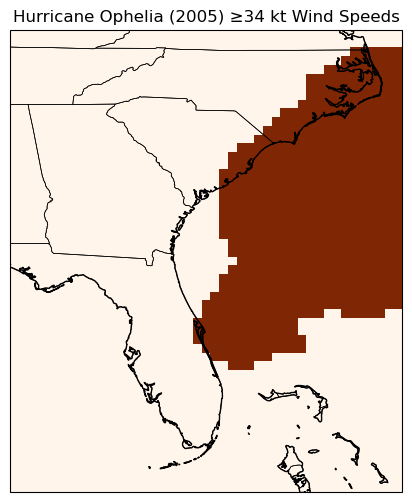

In [15]:
# Add in plot here to check data before land/sea mask and CONUS mask

# Reduce time dimension
footprint_mask_over_time = footprint_mask.any(dim='time').squeeze() # Had to squeeze - shape was (time, lat, lon)

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the footprint
mesh = ax.pcolormesh(
    ERA5Reanalysis.longitude,
    ERA5Reanalysis.latitude,
    footprint_mask_over_time,
    transform=ccrs.PlateCarree(),
    shading='auto',
    cmap='Oranges'
)

# Add coastlines and states
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.STATES, linewidth=0.5)

plt.title('Hurricane Ophelia (2005) ≥34 kt Wind Speeds')
plt.show()

In [16]:
# Everything above includes lat/lon coordinates over land AND ocean.
# Apply land-sea mask from ERA5 data (separate download from single levels options) and mask only points over land
# https://codes.ecmwf.int/grib/param-db/172
# Use 0.5, or lower value due to coastal geography?

lsm_ds = xr.open_dataset('land_sea_mask.nc')
print(lsm_ds)

<xarray.Dataset> Size: 27kB
Dimensions:     (valid_time: 1, latitude: 53, longitude: 121)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2016-10-06
  * latitude    (latitude) float64 424B 37.0 36.75 36.5 ... 24.5 24.25 24.0
  * longitude   (longitude) float64 968B -105.0 -104.8 -104.5 ... -75.25 -75.0
    expver      <U4 16B ...
Data variables:
    lsm         (valid_time, latitude, longitude) float32 26kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-13T06:54 GRIB to CDM+CF via cfgrib-0.9.1...


getfattr: /home/hildebr1/ATMS: No such file or directory
getfattr: 596/Ophelia2005/land_sea_mask.nc: No such file or directory


In [17]:
# Flip latitude so it is descending (to match ERA5 temp latitude)
lsm_ds = lsm_ds.sel(latitude=lsm_ds.latitude[::-1])

In [18]:
# Convert longitude to 0-360 format to match ERA5 temp longitude

lsm_ds = lsm_ds.assign_coords(longitude=(lsm_ds.longitude % 360))
lsm_ds = lsm_ds.sortby('longitude')
# Check that those worked
print(lsm_ds)


<xarray.Dataset> Size: 27kB
Dimensions:     (valid_time: 1, latitude: 53, longitude: 121)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2016-10-06
  * latitude    (latitude) float64 424B 24.0 24.25 24.5 ... 36.5 36.75 37.0
    expver      <U4 16B ...
  * longitude   (longitude) float64 968B 255.0 255.2 255.5 ... 284.5 284.8 285.0
Data variables:
    lsm         (valid_time, latitude, longitude) float32 26kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-13T06:54 GRIB to CDM+CF via cfgrib-0.9.1...


In [19]:
# Convert boolean to float so it can be interpolated to ERA5 temp data (will get error otherwise)

land_mask = lsm_ds.lsm > 0.3

land_mask_float = land_mask.astype(float)

In [20]:
# Interpolate land sea mask to ERA5 grid

land_mask_interp = land_mask_float.interp_like(ERA5Reanalysis)

In [21]:
# Convert back to boolean mask - using 0.3 instead of 0.5 to better account for coastal regions

land_mask_final = land_mask_interp > 0.3

In [22]:
# Check the number of over-land points to make sure this worked and is not zero

print(land_mask_final.sum().item())

1029


In [23]:
# Import 2025 TIGER/Line shapefile for continental US states. Adding this so that only continental US land masses are included.

states = gpd.read_file('tl_2025_us_state.shp')

In [24]:
# Select only the coastal southeast states of interest 

states_of_interest = ['Texas', 'Louisiana', 'Mississippi', 'Alabama', 'Florida', 'Georgia', 'South Carolina', 'North Carolina']

se_states = states[states['NAME'].isin(states_of_interest)].copy()

# Convert longitude to 0-360 format
def shift_lon_360(x, y, z=None):
    return (x % 360, y)

se_states['geometry'] = se_states['geometry'].apply(
    lambda geom: transform(shift_lon_360, geom)
)

# Merge into one polygon
se_region_polygon = se_states.geometry.union_all()

In [25]:
# Build region polygon mask on ERA5 grid

mask = np.zeros(
    (len(ERA5Reanalysis.latitude), len(ERA5Reanalysis.longitude)),
    dtype=bool
)

for i, lat in enumerate(ERA5Reanalysis.latitude.values):
    for j, lon in enumerate(ERA5Reanalysis.longitude.values):
        pt = Point(lon, lat) 
        mask[i, j] = se_region_polygon.contains(pt)

# Convert to array
se_region_mask = xr.DataArray(
    mask,
    coords={
        'latitude': ERA5Reanalysis.latitude,
        'longitude': ERA5Reanalysis.longitude
    },
    dims=('latitude', 'longitude')
)

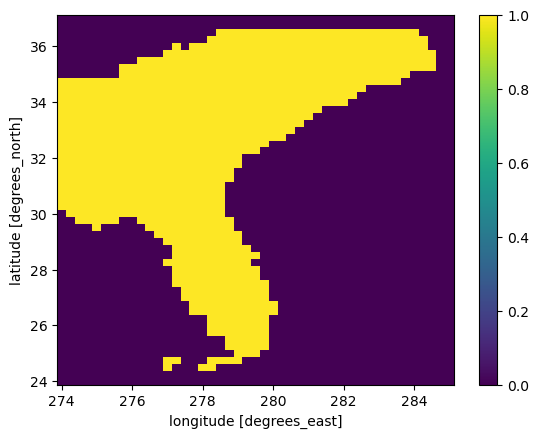

In [26]:
# Plot for sanity check

se_region_mask.plot()

In [27]:
# Combine with footprint mask (for points with wind criteria AND over land)
combined_mask = footprint_mask & land_mask_final & se_region_mask
print(combined_mask.sum().item())

422


In [28]:
print(combined_mask.dims)

('time', 'latitude', 'longitude', 'valid_time')


('latitude', 'longitude')


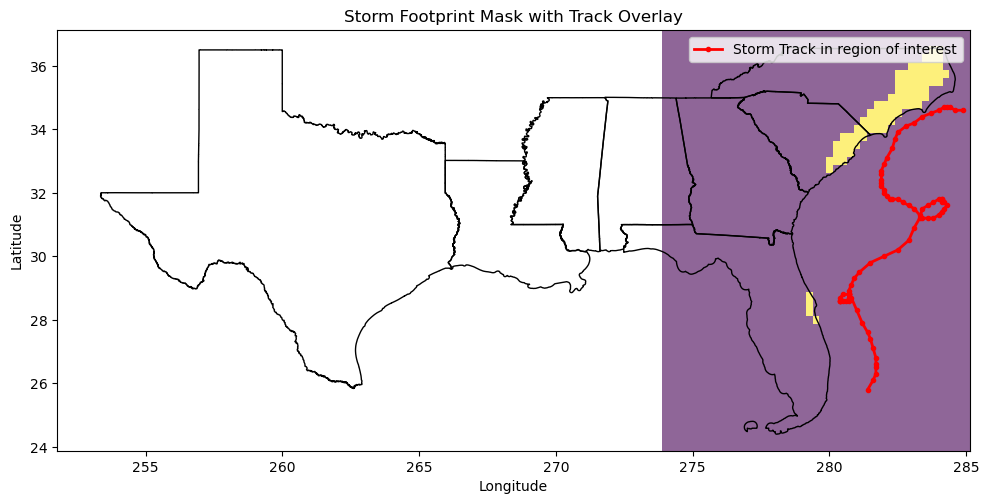

In [29]:
# Plot CONUS state map, domain of interest, and storm track for sanity check
final_mask_2d = combined_mask.any(dim=['time', 'valid_time'])
print(final_mask_2d.dims)

fig, ax = plt.subplots(figsize=(10, 8))

final_mask_2d.astype(int).plot.imshow(
    ax=ax,
    cmap='viridis',
    alpha=0.6,
    add_colorbar=False
)

se_states.boundary.plot(ax=ax, color='black', linewidth=1)

ax.plot(
    lon_c.where(in_domain, drop=True),
    lat_c.where(in_domain, drop=True),
    color='red',
    linewidth=2,
    marker='o',
    markersize=3,
    label='Storm Track in region of interest'
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Storm Footprint Mask with Track Overlay")
ax.legend()
plt.tight_layout()
plt.show()

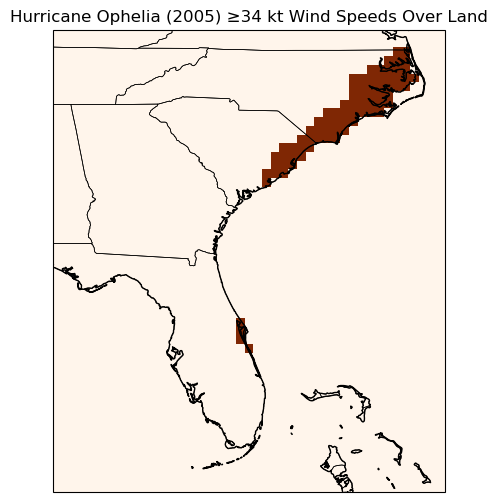

In [30]:
# Plot only over-land >34kt data

# Reduce time dimension
mask_over_time = combined_mask.any(dim='time').squeeze()

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the footprint
mesh = ax.pcolormesh(
    ERA5Reanalysis.longitude,
    ERA5Reanalysis.latitude,
    mask_over_time,
    transform=ccrs.PlateCarree(),
    shading='auto',
    cmap='Oranges'
)

# Add coastlines and states
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.STATES, linewidth=0.5)
#ax.set_extent([274, 285, 24, 38], crs=ccrs.PlateCarree())

plt.title('Hurricane Ophelia (2005) ≥34 kt Wind Speeds Over Land')
plt.show()

In [31]:
# To segment temperature data by time period, need to build a time-varying mask at each grid cell to define before storm, during storm, and after storm
# Also want to mask TCWV for later analysis

mask3d = combined_mask.squeeze('valid_time')
temp = ERA5Reanalysis.VAR_2T
tcwv = ERA5Reanalysis.TCWV

# Consider all cells that were ever impacted by storm-force winds
spatial_mask = mask3d.any(dim='time')

# Define the first and last impacted time index per cell
first_idx = mask3d.argmax(dim='time')
last_idx = mask3d[::-1].argmax(dim='time')
last_idx = mask3d.sizes['time']-1-last_idx

# Convert indices to datetime
time_coord = mask3d['time']
first_storm_time = time_coord.isel(time=first_idx).where(spatial_mask)
last_storm_time  = time_coord.isel(time=last_idx).where(spatial_mask)

# Broadcast time to 3D
time3d = temp['time'].broadcast_like(mask3d)

# Set points for before, during, and after masks
before_mask = (
    (time3d >= (first_storm_time - np.timedelta64(14, 'D'))) &
    (time3d < first_storm_time)
)

during_mask = (
    (time3d >= first_storm_time) &
    (time3d <= last_storm_time)
)

after_mask = (
    (time3d > last_storm_time) &
    (time3d <= (last_storm_time + np.timedelta64(35, 'D')))
)

# Restrict to impacted cells (from spatial mask)
before_mask = before_mask & spatial_mask
during_mask = during_mask & spatial_mask
after_mask  = after_mask & spatial_mask

# Apply masks to temperature data
temp_before = temp.where(before_mask)
temp_during = temp.where(during_mask)
temp_after = temp.where(after_mask)
tcwv_before = tcwv.where(before_mask)
tcwv_during = tcwv.where(during_mask)
tcwv_after = tcwv.where(after_mask)

storm_times = xr.Dataset({
    'temp_before_storm': temp_before,
    'temp_during_storm': temp_during,
    'temp_after_storm': temp_after,
    'tcwv_before_storm': tcwv_before,
    'tcwv_during_storm': tcwv_during,
    'tcwv_after_storm': tcwv_after,
    'first_storm_time': first_storm_time,
    'last_storm_time': last_storm_time
})

In [32]:
# Write to netcdf file to use for analysis with other storms
storm_times.to_netcdf('Ophelia_temp_tcwv.nc')

In [33]:
# Sanity check first and last storm times, and counts 

print(first_storm_time)
print(last_storm_time)

print("Impacted cells:", spatial_mask.sum().item())
print("Cells with valid first time:", first_storm_time.notnull().sum().item())
print("Cells with valid last time:", last_storm_time.notnull().sum().item())

<xarray.DataArray 'time' (latitude: 53, longitude: 45)> Size: 19kB
array([['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ...,
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT']],
      shape=(53, 45), dtype='datetime64[ns]')
Coordinates:
    time        (latitude, longitude) datetime64[ns] 19kB 2005-08-21 ... 2005...
    number      int64 8B 0
    valid_time  datetime64[ns] 8B 2016-10-06
    expver      <U4 16B '0001'
  * latitude    (latitude) float64 424B 37.0 36.75 36.5 ... 24.5 24.25 24.0
  * longitude   (longitude) float64 360B 274.0 274.2 274.5 ... 284.5 284.8 285.0
Attributes:
    long_name:  time
<xarray.DataArray 'time' (latitude: 53, longitude: 45)> Size: 19kB
array([['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT',

In [34]:
# Sanity check number of grid points in each time period

count_before = temp_before.notnull().sum(dim=['latitude', 'longitude'])
count_during = temp_during.notnull().sum(dim=['latitude', 'longitude'])
count_after  = temp_after.notnull().sum(dim=['latitude', 'longitude'])

print(count_before.max().item(), count_during.max().item(), count_after.max().item())

77 49 77


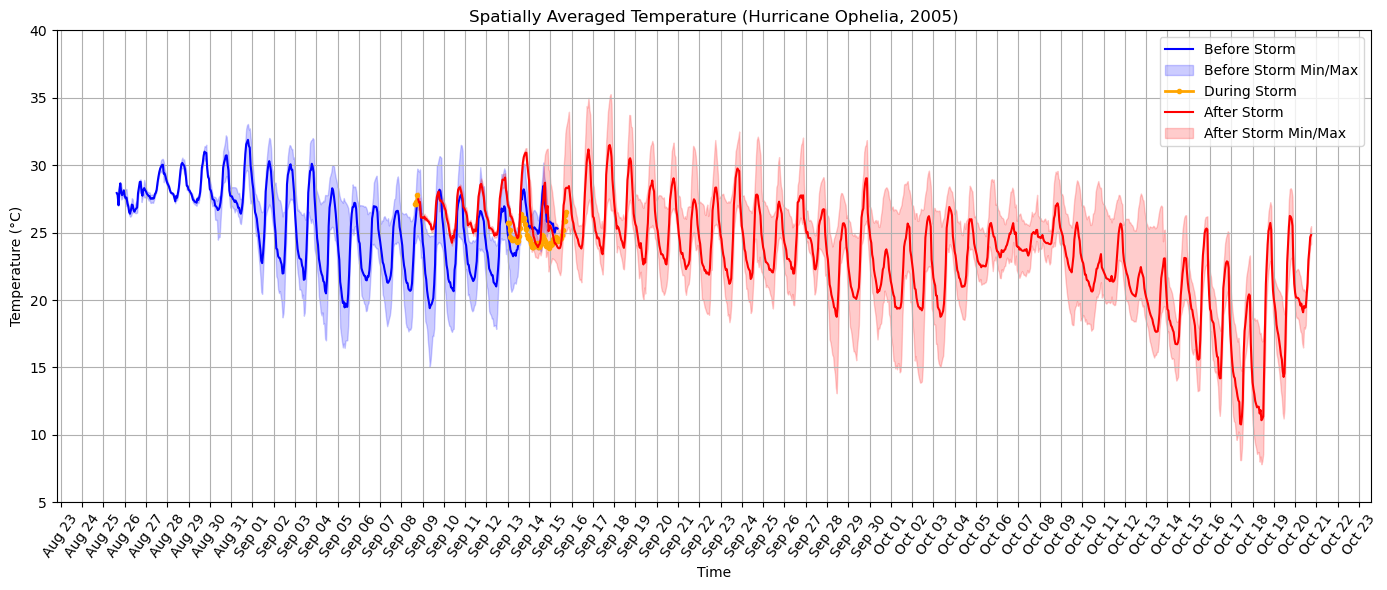

In [35]:
# Plot temperature in the before, during, and after storm time periods - Mean, Max, Min
# Added marks to the during period because number of data points is fairly small

temp_before_avg = storm_times['temp_before_storm'].mean(dim=['latitude','longitude'], skipna=True) - 273.15
temp_before_min = storm_times['temp_before_storm'].min(dim=['latitude','longitude'], skipna=True) - 273.15
temp_before_max = storm_times['temp_before_storm'].max(dim=['latitude','longitude'], skipna=True) - 273.15
temp_during_avg = storm_times['temp_during_storm'].mean(dim=['latitude','longitude'], skipna=True) - 273.15
temp_during_min = storm_times['temp_during_storm'].min(dim=['latitude','longitude'], skipna=True) - 273.15
temp_during_max = storm_times['temp_during_storm'].max(dim=['latitude','longitude'], skipna=True) - 273.15
temp_after_avg  = storm_times['temp_after_storm'].mean(dim=['latitude','longitude'], skipna=True) - 273.15
temp_after_min = storm_times['temp_after_storm'].min(dim=['latitude','longitude'], skipna=True) - 273.15
temp_after_max = storm_times['temp_after_storm'].max(dim=['latitude','longitude'], skipna=True) - 273.15

plt.figure(figsize=(14,6))

plt.plot(temp_before_avg.time, temp_before_avg, color='blue', label='Before Storm')
plt.fill_between(temp_before_avg.time, temp_before_min, temp_before_max, color='blue', alpha=0.2, label='Before Storm Min/Max')

plt.plot(temp_during_avg.time, temp_during_avg, color='orange', marker='o', linewidth=2, markersize=3, label='During Storm')

plt.plot(temp_after_avg.time, temp_after_avg, color='red', label='After Storm')
plt.fill_between(temp_after_avg.time, temp_after_min, temp_after_max, color='red', alpha=0.2, label='After Storm Min/Max')

ax = plt.gca()
ax.set_ylim(5,40)

# One tick per day
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=55)

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Spatially Averaged Temperature (Hurricane Ophelia, 2005)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

/home/hildebr1/envs/xarray-climate/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/hildebr1/envs/xarray-climate/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/hildebr1/envs/xarray-climate/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


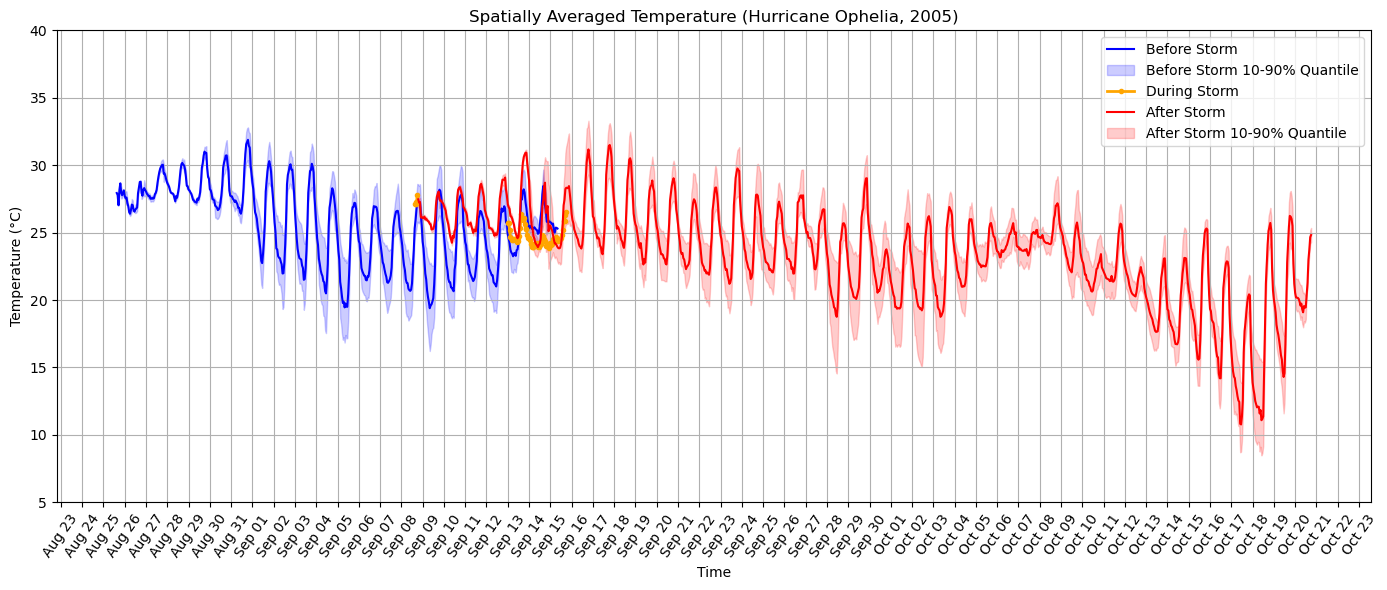

In [36]:
# Plot temperature in the before, during, and after storm time periods - Mean, 10% - 90% Quantiles
# Added marks to the during period because number of data points is fairly small

temp_before_avg = storm_times['temp_before_storm'].mean(dim=['latitude','longitude'], skipna=True) - 273.15
temp_before_p10 = storm_times['temp_before_storm'].quantile(0.1, dim=['latitude','longitude'],skipna=True) - 273.15
temp_before_p90 = storm_times['temp_before_storm'].quantile(0.9, dim=['latitude','longitude'],skipna=True) - 273.15
temp_during_avg = storm_times['temp_during_storm'].mean(dim=['latitude','longitude'], skipna=True) - 273.15
temp_during_p10 = storm_times['temp_during_storm'].quantile(0.1, dim=['latitude','longitude'],skipna=True) - 273.15
temp_during_p90 = storm_times['temp_during_storm'].quantile(0.9, dim=['latitude','longitude'],skipna=True) - 273.15
temp_after_avg  = storm_times['temp_after_storm'].mean(dim=['latitude','longitude'], skipna=True) - 273.15
temp_after_p10 = storm_times['temp_after_storm'].quantile(0.1, dim=['latitude','longitude'],skipna=True) - 273.15
temp_after_p90 = storm_times['temp_after_storm'].quantile(0.9, dim=['latitude','longitude'],skipna=True) - 273.15

plt.figure(figsize=(14,6))

plt.plot(temp_before_avg.time, temp_before_avg, color='blue', label='Before Storm')
plt.fill_between(temp_before_avg.time, temp_before_p10.values, temp_before_p90.values, color='blue', alpha=0.2, label='Before Storm 10-90% Quantile')

plt.plot(temp_during_avg.time, temp_during_avg, color='orange', marker='o', linewidth=2, markersize=3, label='During Storm')

plt.plot(temp_after_avg.time, temp_after_avg, color='red', label='After Storm')
plt.fill_between(temp_after_avg.time, temp_after_p10.values, temp_after_p90.values, color='red', alpha=0.2, label='After Storm 10-90% Quantile')

ax = plt.gca()
ax.set_ylim(5,40)

# One tick per day
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=55)

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Spatially Averaged Temperature (Hurricane Ophelia, 2005)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
# Timing seems correct - landfall was August 14th and 15th (with a gap in between)
# 2 weeks prior to August 14 is July 31
# 5 weeks after August 15 is September 19

In [38]:
# Check number of valid time points during the storm

print(temp_during_avg.dropna(dim='time'))
print("Number of valid during times:", temp_during_avg.notnull().sum().item())

<xarray.DataArray 'temp_during_storm' (time: 71)> Size: 284B
array([27.100494, 27.14151 , 27.239288, 27.77121 , 25.74112 , 25.699493,
       25.184387, 24.702667, 24.633484, 24.463928, 24.477875, 24.50351 ,
       24.514984, 24.518463, 24.310883, 24.361542, 24.57022 , 24.779205,
       25.346222, 26.358002, 26.041443, 25.942657, 26.067322, 25.637817,
       25.29013 , 25.236542, 24.833008, 24.592743, 24.583801, 24.489868,
       24.170685, 23.90445 , 23.964539, 23.95111 , 24.169312, 24.104614,
       24.076752, 24.203949, 23.950317, 23.954407, 24.095734, 24.147827,
       24.337463, 24.844055, 24.772552, 24.55597 , 24.414429, 24.041443,
       23.976349, 24.14392 , 23.837402, 24.010376, 24.244476, 24.092712,
       24.191437, 24.511993, 24.361938, 24.43692 , 24.686584, 24.513885,
       24.452179, 24.373413, 24.470612, 24.516296, 24.602448, 24.78714 ,
       25.175842, 25.825104, 25.897247, 26.333252, 26.526917],
      dtype=float32)
Coordinates:
  * time        (time) datetime64[ns] 5

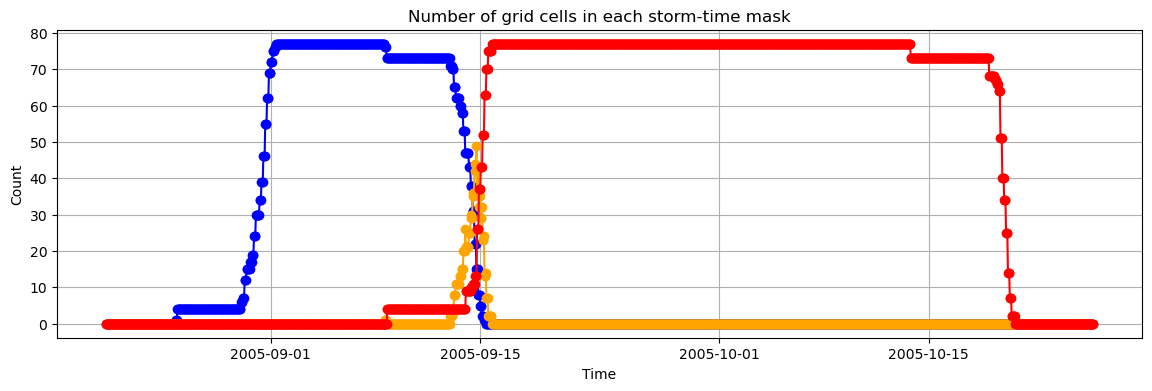

In [39]:
# Sanity check - plot number of grid cells in before/during/after masks

plt.figure(figsize=(14,4))
plt.plot(count_before.time, count_before, marker='o', color='blue')
plt.plot(count_during.time, count_during, marker='o', color='orange')
plt.plot(count_after.time, count_after, marker='o', color='red')
plt.title('Number of grid cells in each storm-time mask')
plt.ylabel('Count')
plt.xlabel('Time')
plt.grid(True)
plt.show()

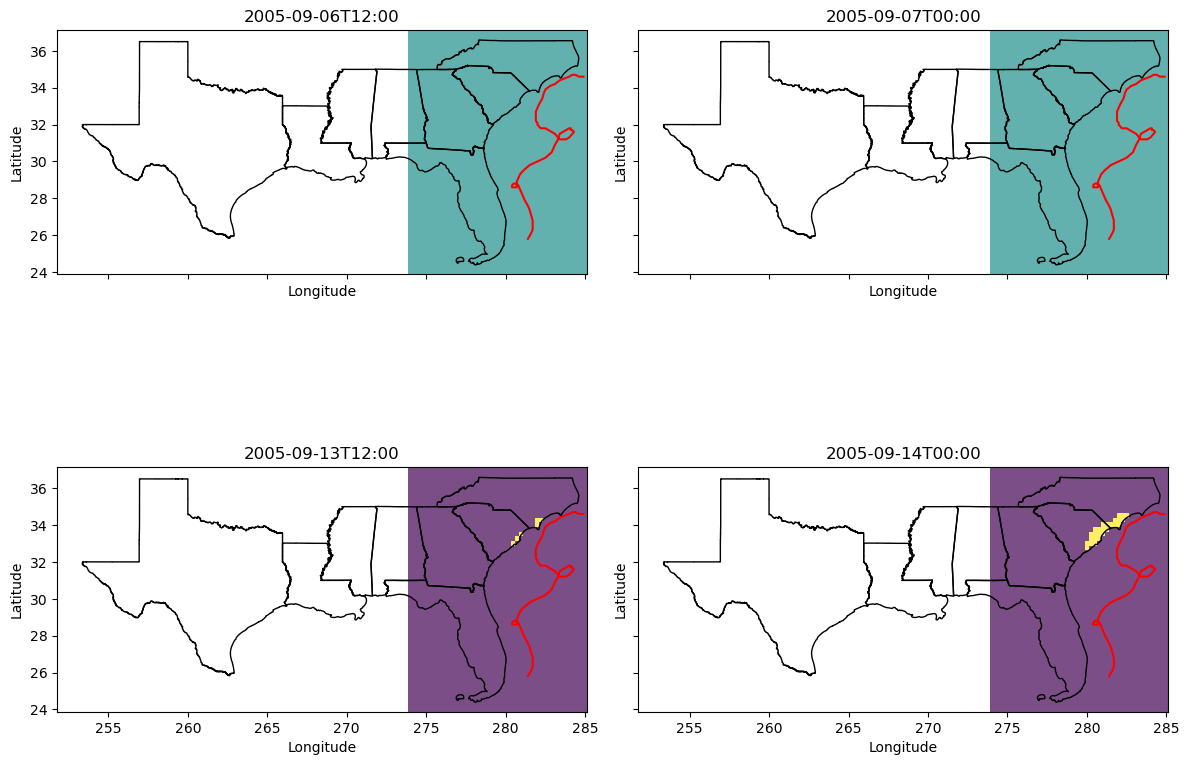

In [40]:
# Sanity check - plot random points before/during/after storm

times_to_plot = ['2005-09-06T12:00','2005-09-07T00:00','2005-09-13T12:00','2005-09-14T00:00']

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

mask3d = combined_mask.squeeze('valid_time')

for ax, t in zip(axes, times_to_plot):
    mask3d.sel(time=t, method='nearest').astype(int).plot.imshow(ax=ax, add_colorbar=False, alpha=0.7)
    se_states.boundary.plot(ax=ax, color='black', linewidth=1)

    ax.plot(lon_c.where(in_domain, drop=True), lat_c.where(in_domain, drop=True), color='red', linewidth=1.5)

    ax.set_title(str(mask3d.sel(time=t, method='nearest').time.values)[:16])
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

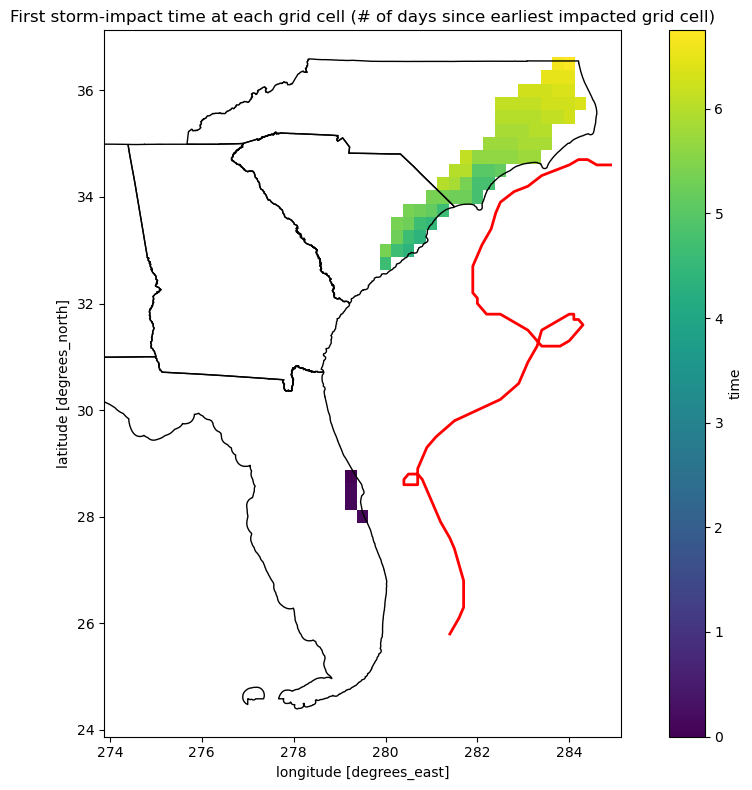

In [41]:
# Sanity check - plot first-impact time map

mask3d = combined_mask.squeeze('valid_time')
spatial_mask = mask3d.any(dim='time')

first_idx = mask3d.argmax(dim='time')
first_storm_time = mask3d['time'].isel(time=first_idx).where(spatial_mask)

# Convert datetime to # of days since earliest impacted time
t0 = first_storm_time.min(skipna=True)

first_storm_day = ((first_storm_time - t0) / np.timedelta64(1, 'D'))

fig, ax = plt.subplots(figsize=(10, 8))

first_storm_day.plot(ax=ax)
se_states.boundary.plot(ax=ax, color='black', linewidth=1)

track_in_domain = (
    (lat_c >= ERA5Reanalysis.latitude.min()) & (lat_c <= ERA5Reanalysis.latitude.max()) &
    (lon_c >= ERA5Reanalysis.longitude.min()) & (lon_c <= ERA5Reanalysis.longitude.max())
)

ax.plot(lon_c.where(track_in_domain, drop=True), lat_c.where(track_in_domain, drop=True), color='red', linewidth=2)

ax.set_title("First storm-impact time at each grid cell (# of days since earliest impacted grid cell)")
plt.tight_layout()
plt.show()

In [42]:
# Check date range of earliest and latest first-impacted times 

print("Earliest impacted grid-cell time:", t0.values)
print("Latest first-impact time:", first_storm_time.max(skipna=True).values)

Earliest impacted grid-cell time: 2005-09-08T15:00:00.000000000
Latest first-impact time: 2005-09-15T09:00:00.000000000


In [43]:
# Sanity check - open output file of temp and tcwv data

filecheck = xr.open_dataset('Ophelia_temp_tcwv.nc')

print(filecheck)

<xarray.Dataset> Size: 91MB
Dimensions:            (time: 1584, latitude: 53, longitude: 45)
Coordinates:
  * latitude           (latitude) float64 424B 37.0 36.75 36.5 ... 24.25 24.0
  * longitude          (longitude) float64 360B 274.0 274.2 ... 284.8 285.0
  * time               (time) datetime64[ns] 13kB 2005-08-21 ... 2005-10-25T2...
    number             int64 8B ...
    valid_time         datetime64[ns] 8B ...
    expver             <U4 16B ...
Data variables:
    temp_before_storm  (time, latitude, longitude) float32 15MB ...
    temp_during_storm  (time, latitude, longitude) float32 15MB ...
    temp_after_storm   (time, latitude, longitude) float32 15MB ...
    tcwv_before_storm  (time, latitude, longitude) float32 15MB ...
    tcwv_during_storm  (time, latitude, longitude) float32 15MB ...
    tcwv_after_storm   (time, latitude, longitude) float32 15MB ...
    first_storm_time   (latitude, longitude) datetime64[ns] 19kB ...
    last_storm_time    (latitude, longitude) datet

getfattr: /home/hildebr1/ATMS: No such file or directory
getfattr: 596/Ophelia2005/Ophelia_temp_tcwv.nc: No such file or directory
